UCI Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      124             91             98      552  34.7   
1           14      195            111             19      317  38.0   
2           10      125            118             60      501  20.9   
3            7       58             89             34      827  42.2   
4            6      123             72             49      380  22.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     1.370   76        0  
1                     1.270   50        1  
2                     0.308   77        1  
3                     1.659   50        1  
4                     2.064   67        1  

Pima Indians Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0           16      103             44             87      659  43.5   
1           10      164            100             39      320  37.1   
2            2     

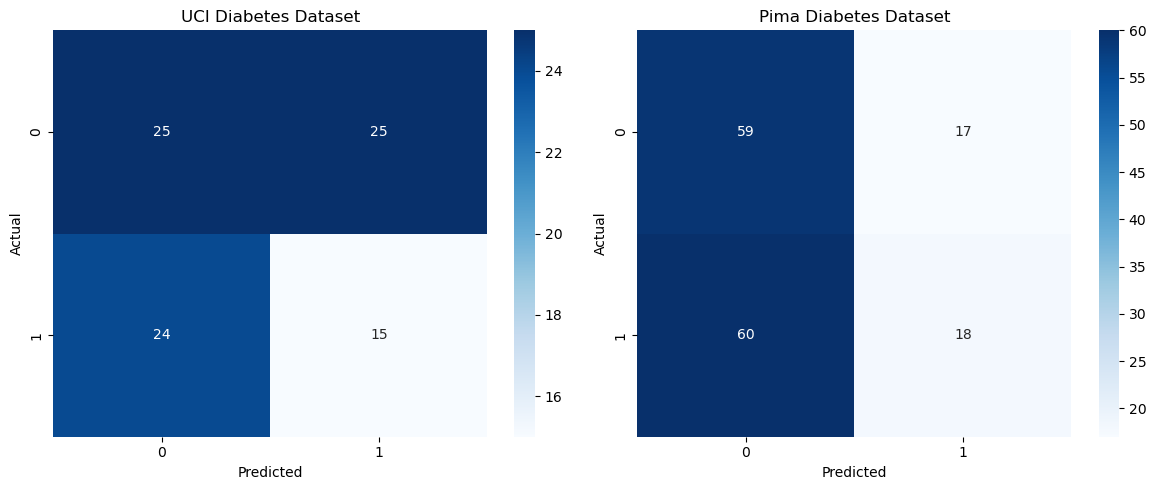

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes.csv")
pima_diabetes = pd.read_csv("pima_diabetes.csv")

# Display Sample Data
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Select Features and Target Variable
features = ["Glucose", "BloodPressure", "BMI"]
target = "Outcome"

X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split Data into Training and Testing Sets
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci,
    y_uci,
    test_size=0.20,
    random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima,
    y_pima,
    test_size=0.20,
    random_state=42
)

# Train Logistic Regression Models
model_uci = LogisticRegression(max_iter=1000)
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LogisticRegression(max_iter=1000)
model_pima.fit(X_train_pima, y_train_pima)

# Make Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

# Evaluate UCI Dataset
accuracy_uci = accuracy_score(y_test_uci, y_pred_uci)
precision_uci = precision_score(y_test_uci, y_pred_uci)
recall_uci = recall_score(y_test_uci, y_pred_uci)
f1_uci = f1_score(y_test_uci, y_pred_uci)

# Evaluate Pima Dataset
accuracy_pima = accuracy_score(y_test_pima, y_pred_pima)
precision_pima = precision_score(y_test_pima, y_pred_pima)
recall_pima = recall_score(y_test_pima, y_pred_pima)
f1_pima = f1_score(y_test_pima, y_pred_pima)

# Display Results
print("\n========================================")
print("UCI Diabetes Dataset - Logistic Regression")
print("========================================")
print(f"Accuracy : {accuracy_uci:.4f}")
print(f"Precision: {precision_uci:.4f}")
print(f"Recall   : {recall_uci:.4f}")
print(f"F1 Score : {f1_uci:.4f}")

print("\n========================================")
print("Pima Diabetes Dataset - Logistic Regression")
print("========================================")
print(f"Accuracy : {accuracy_pima:.4f}")
print(f"Precision: {precision_pima:.4f}")
print(f"Recall   : {recall_pima:.4f}")
print(f"F1 Score : {f1_pima:.4f}")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_test_uci, y_pred_uci),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("UCI Diabetes Dataset")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test_pima, y_pred_pima),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Pima Diabetes Dataset")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()